# 🛠️ Feature Engineering

Preprocessing (topic 03) makes data *usable*. Feature engineering makes it *predictive* — creating, transforming, and selecting the inputs that actually help a model learn. It's widely considered the single highest-leverage skill in classical ML: a well-engineered feature set often beats a fancier algorithm on mediocre features.

📖 Full mathematical explanation (log/Box-Cox transforms, polynomial expansion, selection criteria): [README.md](README.md)


## 1. Setup — A Dataset Worth Engineering

We simulate an e-commerce-style dataset with a date column (rich for decomposition), a right-skewed monetary feature (needs a transform), and several raw numeric features (candidates for interaction terms and selection).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")
np.random.seed(42)

n = 300
dates = pd.date_range("2024-01-01", periods=365, freq="D")   # full year, so every month is represented when sampled
df = pd.DataFrame({
    "order_date": np.random.choice(dates, n),
    "unit_price": np.random.exponential(scale=25, size=n) + 5,   # right-skewed, like real price data
    "quantity": np.random.randint(1, 10, n),
    "customer_age": np.random.normal(35, 12, n).clip(18, 75),
    "delivery_days": np.random.poisson(4, n) + 1,
})
df["total_spend"] = df["unit_price"] * df["quantity"] * np.random.normal(1, 0.05, n)

df.head()


,order_date,unit_price,quantity,customer_age,delivery_days,total_spend
0,2024-04-12,22.025215,8,30.829679,5,173.796389
1,2024-12-14,9.925406,1,44.949664,7,10.106607
2,2024-09-27,16.411150,6,50.443700,4,103.247180
3,2024-04-16,39.081104,1,29.664349,4,42.211995
4,2024-03-12,36.908205,2,29.871105,6,71.077798


## 2. Feature Creation — Date Decomposition

A single `datetime` column is low-value on its own for most models, but decomposes into several high-value features: cyclical patterns (month, day-of-week) and simple flags (is_weekend) that a raw timestamp hides.


In [2]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_month"] = df["order_date"].dt.month
df["order_dayofweek"] = df["order_date"].dt.dayofweek       # 0=Monday ... 6=Sunday
df["is_weekend"] = df["order_dayofweek"].isin([5, 6]).astype(int)

print(df[["order_date", "order_month", "order_dayofweek", "is_weekend"]].head())
print("\nWeekend order share:", df['is_weekend'].mean().round(3))


  order_date  order_month  order_dayofweek  is_weekend
0 2024-04-12            4                4           0
1 2024-12-14           12                5           1
2 2024-09-27            9                4           0
3 2024-04-16            4                1           0
4 2024-03-12            3                1           0

Weekend order share: 0.267


## 3. Feature Creation — Ratios & Interaction Terms

Domain-derived ratios often carry more signal than either raw component alone, and **interaction terms** capture effects that only appear when two features combine (e.g., older customers buying in bulk might behave differently than young bulk-buyers).

⚠️ **Leakage warning:** a ratio feature must only combine *input* columns, never the target. Dividing the target by something and feeding that back in as a feature (e.g. `total_spend / delivery_days` to predict `total_spend`) is **target leakage** — it smuggles the answer into the inputs and makes a model look artificially accurate. The ratio below (`unit_price / delivery_days`) is built only from other input features, so it stays legitimate.


In [3]:
# Ratio feature: ties two raw INPUT columns (never the target) into one more meaningful signal
df["price_per_delivery_day"] = df["unit_price"] / df["delivery_days"]

# Manual interaction term: captures a combined effect neither feature alone represents
df["age_x_quantity"] = df["customer_age"] * df["quantity"]

# PolynomialFeatures: generates ALL interaction + squared terms automatically for a feature subset
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_input = df[["unit_price", "quantity"]]
poly_features = poly.fit_transform(poly_input)
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(["unit_price", "quantity"]))
poly_df.head()


,unit_price,quantity,unit_price^2,unit_price quantity,quantity^2
0,22.025215,8.0,485.110077,176.201717,64.0
1,9.925406,1.0,98.513688,9.925406,1.0
2,16.411150,6.0,269.325849,98.466901,36.0
3,39.081104,1.0,1527.332694,39.081104,1.0
4,36.908205,2.0,1362.215587,73.816410,4.0


## 4. Feature Transformation — Fixing Skew

`unit_price` was generated from an exponential distribution — heavily right-skewed. Many algorithms (especially linear ones) assume roughly symmetric, normally-shaped features. Two standard fixes, compared below:

- **Log transform** — simple, fast, only valid for strictly positive values
- **Box-Cox / Yeo-Johnson (`PowerTransformer`)** — finds the *best* power transform automatically, Yeo-Johnson also handles zero/negative values


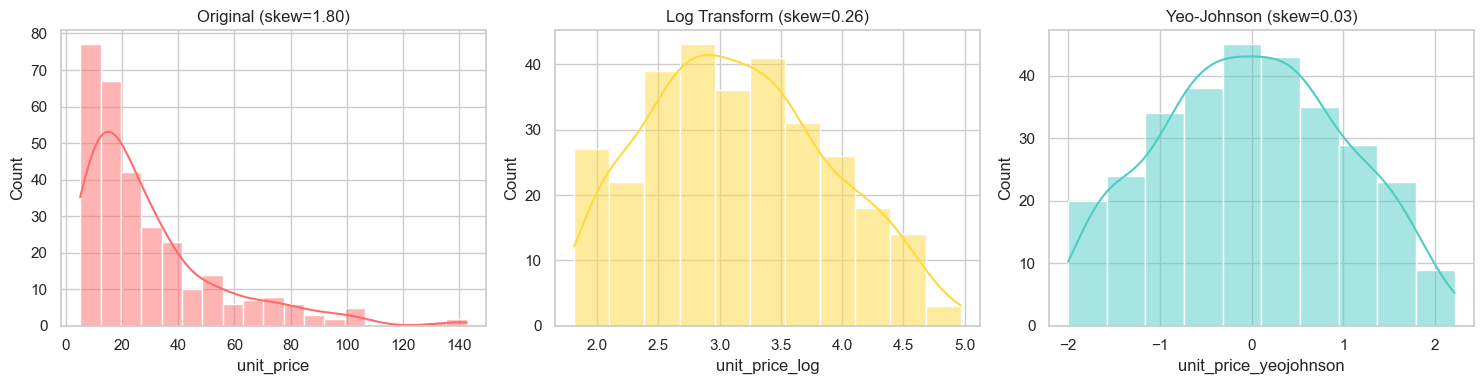

In [4]:
df["unit_price_log"] = np.log1p(df["unit_price"])   # log1p = log(1+x), safe even if x is ever 0

pt = PowerTransformer(method="yeo-johnson")
df["unit_price_yeojohnson"] = pt.fit_transform(df[["unit_price"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["unit_price"], kde=True, ax=axes[0], color="#ff6b6b")
axes[0].set_title(f"Original (skew={df['unit_price'].skew():.2f})")

sns.histplot(df["unit_price_log"], kde=True, ax=axes[1], color="#ffd93d")
axes[1].set_title(f"Log Transform (skew={df['unit_price_log'].skew():.2f})")

sns.histplot(df["unit_price_yeojohnson"], kde=True, ax=axes[2], color="#4ecdc4")
axes[2].set_title(f"Yeo-Johnson (skew={df['unit_price_yeojohnson'].skew():.2f})")

plt.tight_layout()
plt.show()


## 5. Feature Transformation — Binning (Discretization)

Binning converts a continuous variable into ordered categories — useful when a model benefits from a simpler, non-linear-friendly grouping, or for readability in reports (e.g., age brackets instead of raw age).


In [5]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[18, 25, 35, 50, 75],
    labels=["18-25", "26-35", "36-50", "51-75"]
)
print(df["age_group"].value_counts().sort_index())


age_group
18-25     40
26-35     80
36-50    122
51-75     27
Name: count, dtype: int64


## 6. Feature Selection — Filter Methods

Filter methods score each feature independently of any model, using a statistical criterion:

- **Variance Threshold** — drops near-constant features (they carry almost no information, regardless of relationship to the target)
- **Correlation filter** — drops one of any pair of features that are near-duplicates of each other (redundant, and destabilizing for linear models — see topic 02's heatmap discussion)
- **Mutual Information** — measures how much knowing a feature reduces uncertainty about the target, capturing non-linear relationships that Pearson correlation misses


In [6]:
numeric_features = ["unit_price", "quantity", "customer_age", "delivery_days", "age_x_quantity", "price_per_delivery_day"]
X = df[numeric_features]
y = df["total_spend"]

# Variance Threshold: flag near-constant columns (none expected here, but this is the mechanism)
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X)
print("Features kept by variance threshold:", list(X.columns[var_selector.get_support()]))

# Correlation filter: find highly correlated feature pairs (candidates for dropping one)
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_triangle.columns for row in upper_triangle.index
                    if upper_triangle.loc[row, col] > 0.85]
print("Highly correlated pairs (|r| > 0.85):", high_corr_pairs)

# Mutual information: non-linear relationship strength with the target
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nMutual information with total_spend:\n", mi_series)


Features kept by variance threshold: ['unit_price', 'quantity', 'customer_age', 'delivery_days', 'age_x_quantity', 'price_per_delivery_day']
Highly correlated pairs (|r| > 0.85): []

Mutual information with total_spend:
 unit_price                0.591644
price_per_delivery_day    0.304584
quantity                  0.268395
age_x_quantity            0.217655
delivery_days             0.067480
customer_age              0.000000
dtype: float64


## 7. Feature Selection — Embedded Method (Model-Based Importance)

Embedded methods let a model itself score feature usefulness *while* training. A quick Random Forest's built-in importance (based on how much each feature reduces prediction error across all trees) is a fast, model-aware selection signal — more on how tree-based importance is computed in the Classical ML → Random Forest notebook.


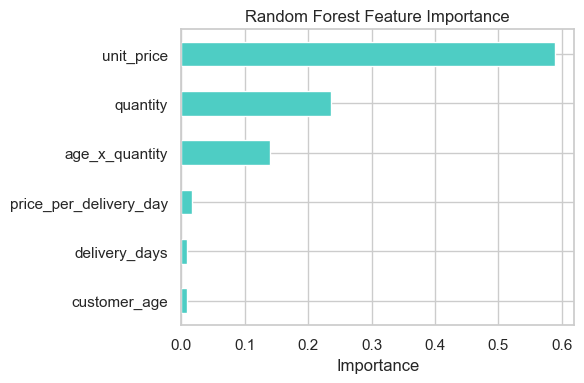

unit_price                0.589695
quantity                  0.236094
age_x_quantity            0.139845
price_per_delivery_day    0.017237
delivery_days             0.008782
customer_age              0.008346
dtype: float64


In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
importance.plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)


## 8. Cyclical Encoding — Fixing the "December → January" Discontinuity

Treating `month` (1–12) as a plain number tells the model that December (12) and January (1) are as far apart as possible — wrong, since they're adjacent. **Cyclical encoding** maps a periodic feature onto a circle using sine and cosine, so the "wrap-around" is represented correctly.


Euclidean distance between December and January (cyclical): 0.518
Euclidean distance between January and June (raw month numbers, |1-6|): 5
-> Dec/Jan are numerically close under cyclical encoding, unlike with the raw month number.


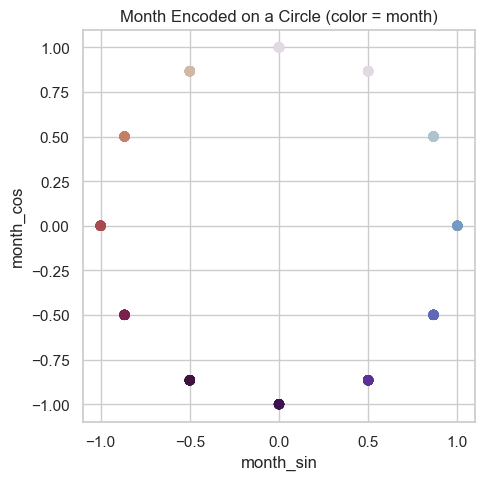

In [8]:
df["month_sin"] = np.sin(2 * np.pi * df["order_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["order_month"] / 12)

# Verify: December (12) and January (1) should now be close in (sin, cos) space
dec_point = df.loc[df["order_month"] == 12, ["month_sin", "month_cos"]].iloc[0]
jan_point = df.loc[df["order_month"] == 1, ["month_sin", "month_cos"]].iloc[0]
distance = np.sqrt(((dec_point - jan_point) ** 2).sum())
print(f"Euclidean distance between December and January (cyclical): {distance:.3f}")
print(f"Euclidean distance between January and June (raw month numbers, |1-6|): {abs(1 - 6)}")
print("-> Dec/Jan are numerically close under cyclical encoding, unlike with the raw month number.")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(df["month_sin"], df["month_cos"], c=df["order_month"], cmap="twilight", s=40)
ax.set_title("Month Encoded on a Circle (color = month)")
ax.set_xlabel("month_sin"); ax.set_ylabel("month_cos")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## 9. Target (Mean) Encoding

Instead of one-hot encoding a category into many columns, **target encoding** replaces each category with the mean target value for that category — compact (one column, any cardinality) and can capture more signal than one-hot for high-cardinality features. The tradeoff: it leaks target information into the feature, so it must be computed only on training data (or with cross-fold encoding) in a real pipeline.


In [9]:
# Mean-encode order_dayofweek using total_spend (illustrative — see leakage warning below)
day_means = df.groupby("order_dayofweek")["total_spend"].mean()
df["dayofweek_target_encoded"] = df["order_dayofweek"].map(day_means)

print("Mean total_spend per day-of-week:\n", day_means.round(2))
print("\nSample encoded values:\n", df[["order_dayofweek", "dayofweek_target_encoded"]].head())
print("\n⚠️ In a real pipeline: compute day_means on the TRAINING fold only, then map onto validation/test —")
print("   computing it on the full dataset (as done here for illustration) leaks target info into the feature.")


Mean total_spend per day-of-week:
 order_dayofweek
0    138.27
1    129.75
2    145.43
3    141.51
4    131.85
5    158.16
6    114.18
Name: total_spend, dtype: float64

Sample encoded values:
    order_dayofweek  dayofweek_target_encoded
0                4                131.850447
1                5                158.162434
2                4                131.850447
3                1                129.749348
4                1                129.749348

⚠️ In a real pipeline: compute day_means on the TRAINING fold only, then map onto validation/test —
   computing it on the full dataset (as done here for illustration) leaks target info into the feature.


## 10. Recursive Feature Elimination (RFE) — a Wrapper Method

Unlike filter methods (fast, model-agnostic) or embedded methods (one model's opinion), **RFE** repeatedly trains a model, drops the least important feature, and retrains — directly optimizing for "which feature subset does *this* model perform best with." More expensive, often more accurate for a specific downstream model.


In [10]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe_features = ["unit_price", "quantity", "customer_age", "delivery_days", "age_x_quantity", "price_per_delivery_day"]
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(df[rfe_features], df["total_spend"])

ranking = pd.Series(rfe.ranking_, index=rfe_features).sort_values()
print("RFE feature ranking (1 = selected, higher = eliminated earlier):\n", ranking)
print("\nSelected features:", list(pd.Index(rfe_features)[rfe.support_]))


RFE feature ranking (1 = selected, higher = eliminated earlier):
 unit_price                1
quantity                  1
delivery_days             1
price_per_delivery_day    2
customer_age              3
age_x_quantity            4
dtype: int64

Selected features: ['unit_price', 'quantity', 'delivery_days']


## 11. Permutation Importance — Model-Agnostic Importance

Tree-based `.feature_importances_` (section 7) only works for tree models and can be biased toward high-cardinality features. **Permutation importance** works for *any* fitted model: shuffle one feature's values (breaking its relationship with the target), measure how much performance drops — a bigger drop means the feature mattered more.


In [11]:
from sklearn.inspection import permutation_importance

rf_for_perm = RandomForestRegressor(n_estimators=100, random_state=42)
rf_for_perm.fit(X, y)

perm_result = permutation_importance(rf_for_perm, X, y, n_repeats=10, random_state=42)
perm_importance = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

print("Permutation importance (mean performance drop when shuffled):\n", perm_importance.round(4))
print("\n-> Compare this ranking to the Random Forest .feature_importances_ ranking in section 7 —")
print("   broadly similar here since both measure the same underlying relationships.")


Permutation importance (mean performance drop when shuffled):
 unit_price                1.4467
quantity                  0.4474
age_x_quantity            0.1679
price_per_delivery_day    0.0121
customer_age              0.0049
delivery_days             0.0032
dtype: float64

-> Compare this ranking to the Random Forest .feature_importances_ ranking in section 7 —
   broadly similar here since both measure the same underlying relationships.


## 12. PCA as Feature Reduction — a Preview

Instead of *selecting* a subset of existing features, PCA *creates* new features (principal components) that are linear combinations of the originals, ranked by how much variance they capture. Full derivation lives in the Unsupervised notebooks (Classical ML) — here's the mechanism as a feature engineering tool.


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS

pca_features = ["unit_price", "quantity", "customer_age", "delivery_days"]
X_scaled = SS().fit_transform(df[pca_features])

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

print("Original feature count:", len(pca_features))
print("Reduced to:", components.shape[1], "principal components")
print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))
print("Total variance retained:", pca.explained_variance_ratio_.sum().round(3))


Original feature count: 4
Reduced to: 2 principal components
Variance explained by each component: [0.28  0.268]
Total variance retained: 0.549


## 13. Quantile-Based Binning — `pd.qcut` vs `pd.cut`

Topic 03 introduced fixed-width bins (`pd.cut`) via `age_group`. `pd.qcut` instead creates bins with **equal sample counts** (quantile-based) — useful when fixed-width bins would leave some bins nearly empty on a skewed feature.


In [13]:
fixed_bins = pd.cut(df["unit_price"], bins=4)
quantile_bins = pd.qcut(df["unit_price"], q=4)

print("Fixed-width bins (pd.cut) — sample counts:\n", fixed_bins.value_counts().sort_index())
print("\nQuantile bins (pd.qcut) — sample counts:\n", quantile_bins.value_counts().sort_index())
print("\n-> unit_price is right-skewed (built from an exponential distribution), so fixed-width bins")
print("   are unevenly populated, while quantile bins are forced to be roughly equal-sized.")


Fixed-width bins (pd.cut) — sample counts:
 unit_price
(4.992, 39.5]       235
(39.5, 73.87]        42
(73.87, 108.24]      20
(108.24, 142.61]      3
Name: count, dtype: int64

Quantile bins (pd.qcut) — sample counts:
 unit_price
(5.129, 12.309]     75
(12.309, 21.449]    75
(21.449, 37.115]    75
(37.115, 142.61]    75
Name: count, dtype: int64

-> unit_price is right-skewed (built from an exponential distribution), so fixed-width bins
   are unevenly populated, while quantile bins are forced to be roughly equal-sized.


## 14. Feature Crosses — Combining Categoricals

A **feature cross** combines two categorical columns into one new categorical column representing their joint value — capturing interaction effects a model might not otherwise find (e.g., "weekend AND high price" might behave differently than either alone).


In [14]:
df["weekend_x_price_tier"] = (
    df["is_weekend"].map({0: "weekday", 1: "weekend"})
    + "_"
    + pd.qcut(df["unit_price"], q=2, labels=["low_price", "high_price"]).astype(str)
)

print(df["weekend_x_price_tier"].value_counts())
print("\nMean spend per cross category:\n", df.groupby("weekend_x_price_tier")["total_spend"].mean().round(2))


weekend_x_price_tier
weekday_low_price     111
weekday_high_price    109
weekend_high_price     41
weekend_low_price      39
Name: count, dtype: int64

Mean spend per cross category:
 weekend_x_price_tier
weekday_high_price    212.79
weekday_low_price      62.15
weekend_high_price    205.01
weekend_low_price      57.04
Name: total_spend, dtype: float64


## 15. Feature Hashing — Encoding Extremely High Cardinality

One-hot encoding a column with thousands of unique values (e.g. user IDs, product SKUs) is impractical. The **hashing trick** maps categories into a small, fixed number of columns via a hash function — no fitted vocabulary needed, constant memory, at the cost of rare (and usually harmless) hash collisions.


In [15]:
from sklearn.feature_extraction import FeatureHasher

# Simulate a very high-cardinality ID column
np.random.seed(11)
high_card_ids = [f"user_{i}" for i in np.random.randint(0, 5000, size=len(df))]

hasher = FeatureHasher(n_features=8, input_type="string")
hashed = hasher.transform([[uid] for uid in high_card_ids]).toarray()

print(f"Original cardinality: {len(set(high_card_ids))} unique IDs")
print(f"Hashed representation shape: {hashed.shape} (fixed at 8 columns regardless of cardinality)")
print("\nFirst 3 hashed rows:\n", hashed[:3])


Original cardinality: 292 unique IDs
Hashed representation shape: (300, 8) (fixed at 8 columns regardless of cardinality)

First 3 hashed rows:
 [[ 0.  0.  0. -1.  0.  0.  0.  0.]
 [-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.]]


## ✅ Key Takeaways

- Feature creation (date decomposition, ratios, interaction terms) often unlocks more predictive power than switching algorithms — always exhaust domain-driven feature ideas first.
- Log/Yeo-Johnson transforms reduce skew, directly helping linear models' assumptions; check the `.skew()` value before and after, don't just eyeball it.
- Filter methods (variance, correlation, mutual information) are fast, model-agnostic first passes; embedded methods (model feature importance) give a second, model-aware opinion — using both together is more reliable than either alone.
- Compare the mutual information and Random Forest importance scores above for `age_x_quantity` and `price_per_delivery_day` (both hand-built) against the raw columns — engineered features routinely rival or beat raw ones, which is exactly why this step isn't optional.
- **Always audit a new feature for target leakage** before trusting its importance score — a feature that's algebraically derived from the target (like the mistake caught and fixed while building this notebook) will look artificially important without being real signal.
- Cyclical encoding (sin/cos) is mandatory for periodic features (month, hour, day-of-week) — a raw integer encoding silently lies about the distance between, e.g., December and January.
- Target encoding is powerful but leakage-prone — always fit it on training data only (or with cross-fold encoding) in a real pipeline, never on the full dataset.
- Filter (fast) → embedded (model-aware) → wrapper (RFE, most expensive but model-optimal) → permutation importance (model-agnostic, works on any fitted model) is a natural progression of feature selection power vs. cost.
- This topic sets up every Classical ML notebook that follows: the feature matrix $X$ they all `fit()` on is the product of exactly this pipeline.

**Next up:** [05_Math_Refresher](../05_Math_Refresher/) — the linear algebra, probability, and statistics underpinning every algorithm ahead.
